# 🔬 IMPLEMENTASI SIKLUS MACHINE LEARNING (8 TAHAPAN)
### **Fokus: Optimasi 8 Fitur Terbaik & Prediksi Tunggal dengan QDA**

In [1]:
# 1. PERSIAPAN LINGKUNGAN KERJA (ENVIRONMENT SETUP)
import pandas as pd
import numpy as np
import pickle
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split

from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

%matplotlib inline
sns.set_theme(style="whitegrid")
warnings.filterwarnings('ignore')
print("✅ Library berhasil di-import!")

✅ Library berhasil di-import!


## 📥 TAHAP 1 & 2: PENGUMPULAN & PEMBERSIHAN DATA
Memuat dataset `diabetes_data_upload.csv`, menghapus data duplikat, dan membersihkan spasi pada nama kolom.

In [2]:
# Load Data
df_raw = pd.read_csv('diabetes_data_upload.csv')
print(f"Dimensi awal: {df_raw.shape[0]} baris.")

# Bersihkan Duplikat & Spasi Kolom
df_cleaned = df_raw.drop_duplicates()
df_cleaned.columns = df_cleaned.columns.str.strip()

print(f"Dimensi setelah dibersihkan: {df_cleaned.shape[0]} baris.")
display(df_cleaned.head())

Dimensi awal: 520 baris.
Dimensi setelah dibersihkan: 251 baris.


,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,Male,No,Yes,No,Yes,No,No,No,Yes,No,Yes,No,Yes,Yes,Yes,Positive
1,58,Male,No,No,No,Yes,No,No,Yes,No,No,No,Yes,No,Yes,No,Positive
2,41,Male,Yes,No,No,Yes,Yes,No,No,Yes,No,Yes,No,Yes,Yes,No,Positive
3,45,Male,No,No,Yes,Yes,Yes,Yes,No,Yes,No,Yes,No,No,No,No,Positive
4,60,Male,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Positive


## ⚙️ TAHAP 3: REKAYASA FITUR & EKSPOR DATA PREPROCESSING
Mengubah nilai teks (Yes/No, Male/Female) menjadi angka biner (1/0), lalu menyimpannya ke dalam file CSV baru.

In [3]:
df_encoded = df_cleaned.copy()
le = LabelEncoder()

# Transformasi Teks ke Angka
for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        df_encoded[col] = le.fit_transform(df_encoded[col])

# EKSPOR DATA HASIL PREPROCESSING
nama_file_output = 'dataset_diabetes_preprocessed.csv'
df_encoded.to_csv(nama_file_output, index=False)
print(f"💾 EXPORT STATUS: Berhasil menyimpan data bersih ke '{nama_file_output}'")

display(df_encoded.head())

💾 EXPORT STATUS: Berhasil menyimpan data bersih ke 'dataset_diabetes_preprocessed.csv'


,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,1,0,1,0,1,0,0,0,1,0,1,0,1,1,1,1
1,58,1,0,0,0,1,0,0,1,0,0,0,1,0,1,0,1
2,41,1,1,0,0,1,1,0,0,1,0,1,0,1,1,0,1
3,45,1,0,0,1,1,1,1,0,1,0,1,0,0,0,0,1
4,60,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1


## 🎯 TAHAP 3B: SELEKSI 8 FITUR TERBAIK (MUTUAL INFORMATION)
Mereduksi dimensi data dengan mengambil 8 gejala yang paling berpengaruh terhadap target diagnosis.

💡 8 Fitur Terpilih Berdasarkan Pengaruh Tertinggi:
1. Polyuria
2. Polydipsia
3. partial paresis
4. sudden weight loss
5. Itching
6. Alopecia
7. Polyphagia
8. Gender


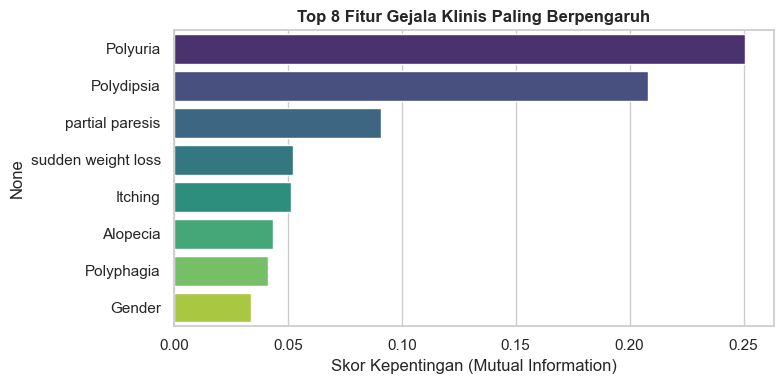

In [4]:
X_temp = df_encoded.drop('class', axis=1)
y_temp = df_encoded['class']

# Hitung skor Mutual Information
mi_scores = mutual_info_classif(X_temp, y_temp, random_state=42)
mi_scores_series = pd.Series(mi_scores, index=X_temp.columns).sort_values(ascending=False)

# Ambil 8 Fitur Teratas
jumlah_fitur_dipilih = 8
fitur_terpilih = mi_scores_series.head(jumlah_fitur_dipilih).index.tolist()
X_selected = X_temp[fitur_terpilih]

print(f"💡 8 Fitur Terpilih Berdasarkan Pengaruh Tertinggi:")
for i, f in enumerate(fitur_terpilih, 1):
    print(f"{i}. {f}")

# Visualisasi 8 Fitur Terbaik
plt.figure(figsize=(8, 4))
sns.barplot(x=mi_scores_series.head(8).values, y=mi_scores_series.head(8).index, palette='viridis')
plt.title('Top 8 Fitur Gejala Klinis Paling Berpengaruh', fontsize=12, fontweight='bold')
plt.xlabel('Skor Kepentingan (Mutual Information)')
plt.tight_layout()
plt.show()

## 🧠 TAHAP 4 & 5: PEMBAGIAN DATA & PELATIHAN MODEL (QDA)
Membagi 8 fitur data menjadi data latih dan uji, lalu melatih model Quadratic Discriminant Analysis (QDA).

In [5]:
# Split Data 80:20
X_train, X_test, y_train, y_test = train_test_split(X_selected, y_temp, test_size=0.2, random_state=42)

# Inisialisasi dan Pelatihan Model QDA
qda_model = QuadraticDiscriminantAnalysis()
qda_model.fit(X_train, y_train)

print("✅ Model QDA berhasil dilatih menggunakan 8 fitur optimal!")
print(f"Data Latih: {X_train.shape[0]} baris | Data Uji: {X_test.shape[0]} baris")

✅ Model QDA berhasil dilatih menggunakan 8 fitur optimal!
Data Latih: 200 baris | Data Uji: 51 baris


## 📈 TAHAP 6: EVALUASI PERFORMA MODEL
Melihat tingkat Akurasi dan Detail Classification Report dari model QDA.

🌟 Akurasi Model QDA: 86.3%

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

 Negatif (0)       0.85      0.69      0.76        16
 Positif (1)       0.87      0.94      0.90        35

    accuracy                           0.86        51
   macro avg       0.86      0.82      0.83        51
weighted avg       0.86      0.86      0.86        51



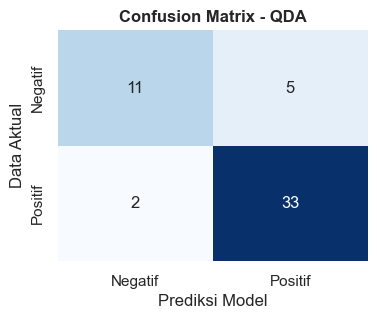

In [6]:
y_pred = qda_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"🌟 Akurasi Model QDA: {acc * 100:.1f}%\n")
print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, target_names=['Negatif (0)', 'Positif (1)']))

# Visualisasi Confusion Matrix
plt.figure(figsize=(4, 3))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Negatif', 'Positif'], yticklabels=['Negatif', 'Positif'])
plt.title('Confusion Matrix - QDA', fontweight='bold')
plt.ylabel('Data Aktual')
plt.xlabel('Prediksi Model')
plt.show()

## 🚀 TAHAP 7: SIMULASI DEPLOYMENT PASIEN BARU
Menguji model dengan memasukkan 8 gejala pasien secara manual. Logika sudah dilengkapi fungsi `.get()` agar kebal terhadap `KeyError`.

In [7]:
print("=== TAHAP 7: SIMULASI PENERAPAN KONSOL MEDIS ===\n")

# 1. Input Gejala Pasien (HANYA 8 FITUR)
data_pasien_baru = {
    'Polyuria': 'Yes',             
    'Polydipsia': 'Yes',           
    'partial paresis': 'No',       
    'sudden weight loss': 'No',    
    'Itching': 'Yes',              
    'Alopecia': 'Yes',             
    'Polyphagia': 'No',            
    'Gender': 'Male'               
}

# Mapping Teks ke Angka
mapping = {"No": 0, "Yes": 1, "Female": 0, "Male": 1}

# 2. Proses Auto-Selection (Aman dari KeyError)
input_siap_prediksi = {}
for kolom in fitur_terpilih:  
    # .get(kolom, 'No') akan otomatis mengisi 'No' jika nama kolom sedikit berbeda
    nilai_mentah = data_pasien_baru.get(kolom, 'No') 
    input_siap_prediksi[kolom] = mapping.get(nilai_mentah, nilai_mentah)

# Konversi ke DataFrame
df_input_pasien = pd.DataFrame([input_siap_prediksi], columns=fitur_terpilih)
print("Data 8 Gejala Klinis Pasien Yang Masuk Ke Sistem:")
display(df_input_pasien)

print("\n=== HASIL DIAGNOSIS SISTEM AI ===")

# 3. Eksekusi Prediksi Menggunakan QDA
pred = qda_model.predict(df_input_pasien)[0]

print("-" * 65)
if pred == 1:
    print("🚨 KESIMPULAN AKHIR: PASIEN DIPREDIKSI POSITIF (BERISIKO DIABETES).")
    print("Sangat direkomendasikan untuk segera melakukan uji klinis gula darah lanjutan di laboratorium.")
else:
    print("🎉 KESIMPULAN AKHIR: PASIEN DIPREDIKSI NEGATIF (AMAN DARI RISIKO DIABETES).")
    print("Pertahankan pola makan dan gaya hidup sehat.")
print("-" * 65)

=== TAHAP 7: SIMULASI PENERAPAN KONSOL MEDIS ===

Data 8 Gejala Klinis Pasien Yang Masuk Ke Sistem:


,Polyuria,Polydipsia,partial paresis,sudden weight loss,Itching,Alopecia,Polyphagia,Gender
0,1,1,0,0,1,1,0,1



=== HASIL DIAGNOSIS SISTEM AI ===
-----------------------------------------------------------------
🚨 KESIMPULAN AKHIR: PASIEN DIPREDIKSI POSITIF (BERISIKO DIABETES).
Sangat direkomendasikan untuk segera melakukan uji klinis gula darah lanjutan di laboratorium.
-----------------------------------------------------------------


## 💾 TAHAP 8: MODEL PERSISTENCE (MENYIMPAN MODEL KE .PKL)
Membekukan model QDA yang sudah dilatih dengan 8 fitur ke dalam file `qda_model_8_features.pkl` agar bisa dipakai di aplikasi lain.

In [8]:
# Tentukan nama file
model_pkl_path = 'qda_model_8_features.pkl'

# Simpan model
with open(model_pkl_path, 'wb') as file:
    pickle.dump(qda_model, file)

print(f"✅ SELURUH SIKLUS SELESAI!")
print(f"💾 Model berhasil dibekukan dan disimpan sebagai: '{model_pkl_path}'")

✅ SELURUH SIKLUS SELESAI!
💾 Model berhasil dibekukan dan disimpan sebagai: 'qda_model_8_features.pkl'
